<a href="https://colab.research.google.com/github/senudidinaya/Dinaya---EfficientNet-B0/blob/Dinaya's-EfficientNet-B0/Dinaya_EfficientNet-B0/notebooks/Dinaya's_Component_%E2%80%94_EfficientNet_B0_(Chest_X_ray_NORMAL_vs_PNEUMONIA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install timm torchmetrics scikit-learn albumentations opencv-python pyyaml

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# COPY with quotes because the folder name has a space
!cp "/content/drive/MyDrive/DL_Assignment/kaggle.json" /content/kaggle.json

# sanity check: the file must show {"username": "...", "key": "..."}
!ls -l /content/kaggle.json
!cat /content/kaggle.json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
-rw------- 1 root root 72 Oct 11 05:12 /content/kaggle.json
{"username":"senudirupasinghe","key":"7780e1bc02634783fb08137fa45db94e"}

In [3]:
# if kaggle.json is already in /content (I see it on the left), copy it to ~/.kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/DL_Assignment/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# install kaggle CLI
!pip -q install kaggle

# download the Chest X-ray dataset zip to /content
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
# unzip into /content/chest_xray
!unzip -q -o /content/chest-xray-pneumonia.zip -d /content

# list the folder to confirm contents
!ls -la /content/chest_xray

total 28
drwxr-xr-x 7 root root 4096 Oct 11 04:10 .
drwxr-xr-x 1 root root 4096 Oct 11 04:09 ..
drwxr-xr-x 5 root root 4096 Oct 11 05:12 chest_xray
drwxr-xr-x 3 root root 4096 Oct 11 05:12 __MACOSX
drwxr-xr-x 4 root root 4096 Oct 11 04:10 test
drwxr-xr-x 4 root root 4096 Oct 11 04:10 train
drwxr-xr-x 4 root root 4096 Oct 11 04:10 val


In [5]:
import os, random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

CFG = {
    "data_root": "/content/chest_xray",
    "img_size": 224,
    "batch_size": 32,
    "epochs": 12,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "patience": 3,                # early stop if AUC doesn't improve
    "model": "efficientnet_b0",
    "ckpt": "/content/efficientnet_b0_best.pt"
}
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]
to3 = transforms.Lambda(lambda img: img.convert("RGB"))

def build_loaders(root, img_size, bs, augment=True, workers=2):
    if augment:
        train_tf = transforms.Compose([
            to3,
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(7),
            transforms.ColorJitter(0.08,0.08,0.08,0.03),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])
    else:
        train_tf = transforms.Compose([
            to3, transforms.Resize((img_size, img_size)),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])

    test_tf = transforms.Compose([
        to3, transforms.Resize((img_size, img_size)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

    tr = datasets.ImageFolder(f"{root}/train", train_tf)
    va = datasets.ImageFolder(f"{root}/val",   test_tf)
    te = datasets.ImageFolder(f"{root}/test",  test_tf)

    return (
        DataLoader(tr, batch_size=bs, shuffle=True,  num_workers=workers, pin_memory=True),
        DataLoader(va, batch_size=bs, shuffle=False, num_workers=workers, pin_memory=True),
        DataLoader(te, batch_size=bs, shuffle=False, num_workers=workers, pin_memory=True),
        tr.classes
    )

train_loader, val_loader, test_loader, class_names = build_loaders(
    CFG["data_root"], CFG["img_size"], CFG["batch_size"], augment=True, workers=2
)
class_names


['NORMAL', 'PNEUMONIA']

In [7]:
import torch
import torch.nn.functional as F
import timm, numpy as np
from torchmetrics.classification import BinaryAUROC

torch.backends.cudnn.benchmark = True  # speedup for fixed image size

def accuracy_from_logits(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

# --- model / optimizer / sched / metrics ---
model = timm.create_model(CFG["model"], pretrained=True, num_classes=2).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG["epochs"])
auroc_metric = BinaryAUROC().to(device)  # for binary P(pneumonia)

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
print("Params (M):", sum(p.numel() for p in model.parameters())/1e6)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}
best_auc, best_state, bad = -1.0, None, 0

for ep in range(1, CFG["epochs"] + 1):

    # ----- Train -----
    model.train()
    running_loss, running_acc, n_batches = 0.0, 0.0, 0

    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(x)
            loss = F.cross_entropy(logits, y)

        scaler.scale(loss).backward()
        # gradient clipping is helpful for stability
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(opt)
        scaler.update()

        running_loss += loss.item()
        running_acc  += accuracy_from_logits(logits, y)
        n_batches    += 1

    tr_loss = running_loss / max(n_batches, 1)
    tr_acc  = running_acc  / max(n_batches, 1)
    sch.step()

    # ----- Validate -----
    model.eval()
    auroc_metric.reset()
    running_vloss, running_vacc, v_batches = 0.0, 0.0, 0

    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device == "cuda")):
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            probs1 = logits.softmax(1)[:, 1]        # P(pneumonia)
            auroc_metric.update(probs1, y)

            vloss = F.cross_entropy(logits, y)
            running_vloss += vloss.item()
            running_vacc  += accuracy_from_logits(logits, y)
            v_batches     += 1

    va_loss = running_vloss / max(v_batches, 1)
    va_acc  = running_vacc  / max(v_batches, 1)
    va_auc  = float(auroc_metric.compute().item())

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["val_auc"].append(va_auc)

    print(f"Epoch {ep:02d}/{CFG['epochs']} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.3f} acc {va_acc:.3f} | "
          f"val AUC {va_auc:.4f}")

    # ----- Early stopping on best AUC -----
    if va_auc > best_auc:
        best_auc = va_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad > CFG["patience"]:
            print("Early stopping triggered.")
            break

# ----- Restore best and save -----
if best_state is not None:
    model.load_state_dict(best_state)
torch.save({"state_dict": model.state_dict(), "best_val_auc": best_auc, "history": history}, CFG["ckpt"])
print("Best val ROC-AUC:", best_auc)

Params (M): 4.01011


/tmp/ipython-input-3020614042.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
/tmp/ipython-input-3020614042.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
/tmp/ipython-input-3020614042.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch 01/12 | train loss 0.337 acc 0.924 | val loss 0.729 acc 0.688 | val AUC 1.0000
Epoch 02/12 | train loss 0.077 acc 0.977 | val loss 0.071 acc 1.000 | val AUC 1.0000
Epoch 03/12 | train loss 0.043 acc 0.985 | val loss 0.019 acc 1.000 | val AUC 1.0000
Epoch 04/12 | train loss 0.050 acc 0.985 | val loss 0.088 acc 0.938 | val AUC 1.0000
Epoch 05/12 | train loss 0.028 acc 0.990 | val loss 0.493 acc 0.875 | val AUC 1.0000
Early stopping triggered.
Best val ROC-AUC: 1.0


In [8]:
import numpy as np
counts = np.bincount(train_loader.dataset.targets, minlength=2)  # [NORMAL, PNEUMONIA]
weights = counts.max() / counts
class_weights = torch.tensor(weights, device=device, dtype=torch.float32)

TEST — Acc: 0.7436 | F1: 0.8291 | Macro-F1: 0.6581 | Sensitivity: 0.9949 | Specificity: 0.3248 | ROC-AUC: 0.9548

Classification report:
               precision    recall  f1-score   support

      NORMAL       0.97      0.32      0.49       234
   PNEUMONIA       0.71      0.99      0.83       390

    accuracy                           0.74       624
   macro avg       0.84      0.66      0.66       624
weighted avg       0.81      0.74      0.70       624



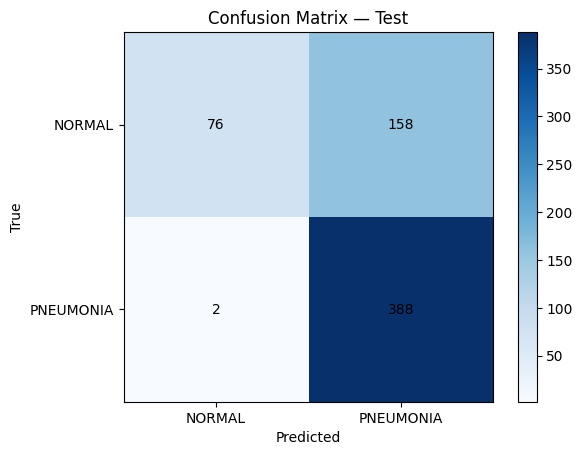

In [9]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, classification_report
)
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

all_probs, all_preds, all_targets = [], [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:,1].cpu().numpy()  # P(pneumonia)
        preds = (probs >= 0.5).astype(int)
        all_probs.append(probs)
        all_preds.append(preds)
        all_targets.append(y.numpy())

y_prob = np.concatenate(all_probs)
y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_targets)

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)                  # binary F1 (positive=pneumonia)
f1m  = f1_score(y_true, y_pred, average='macro') # macro-F1
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)              # sensitivity/recall
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp + 1e-12)                    # specificity
auc  = roc_auc_score(y_true, y_prob)

print(f"TEST — Acc: {acc:.4f} | F1: {f1:.4f} | Macro-F1: {f1m:.4f} | "
      f"Sensitivity: {rec:.4f} | Specificity: {spec:.4f} | ROC-AUC: {auc:.4f}")

print("\nClassification report:\n",
      classification_report(y_true, y_pred, target_names=['NORMAL','PNEUMONIA']))

# Confusion matrix plot
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['NORMAL','PNEUMONIA'])
ax.set_yticklabels(['NORMAL','PNEUMONIA'])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
ax.set_title("Confusion Matrix — Test")
plt.colorbar(im); plt.show()


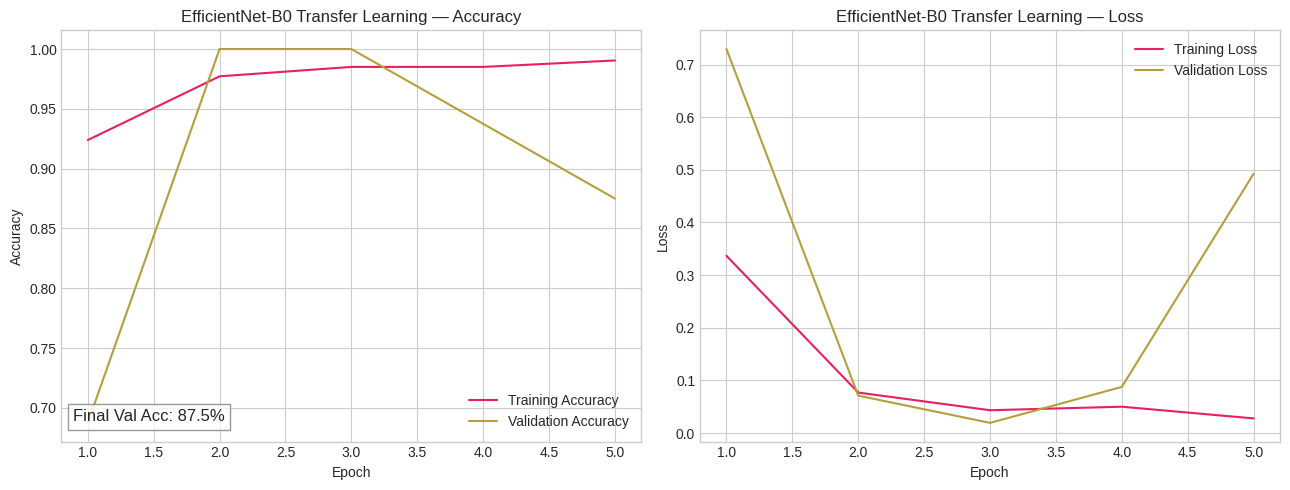

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"])+1)

plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(13,5))

# Accuracy
ax1.plot(epochs, history["train_acc"], label="Training Accuracy", color="#e91e63")
ax1.plot(epochs, history["val_acc"],   label="Validation Accuracy", color="#b59f3b")
ax1.set_title("EfficientNet-B0 Transfer Learning — Accuracy")   # <— change title text here if you want
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.legend(loc="lower right")

# Loss
ax2.plot(epochs, history["train_loss"], label="Training Loss", color="#e91e63")
ax2.plot(epochs, history["val_loss"],   label="Validation Loss", color="#b59f3b")
ax2.set_title("EfficientNet-B0 Transfer Learning — Loss")       # <— change title text here if you want
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.legend(loc="upper right")

# Final validation accuracy (%) label on the figure
final_val_acc = history["val_acc"][-1] if history["val_acc"] else 0.0
ax1.text(0.02, 0.05, f"Final Val Acc: {final_val_acc*100:.1f}%", transform=ax1.transAxes,
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout(); plt.show()


In [11]:
import numpy as np
from sklearn.metrics import roc_curve

# collect val probabilities/targets
model.eval()
val_probs, val_targets = [], []
with torch.no_grad():
    for x,y in val_loader:
        x = x.to(device)
        p1 = torch.softmax(model(x), dim=1)[:,1].detach().cpu().numpy()
        val_probs.append(p1); val_targets.append(y.numpy())
val_prob = np.concatenate(val_probs)
val_true = np.concatenate(val_targets)

# ROC + best threshold (Youden's J)
fpr, tpr, thr = roc_curve(val_true, val_prob)
youden = tpr - fpr
best_idx = youden.argmax()
best_thr = thr[best_idx]
print(f"Best threshold (Youden): {best_thr:.3f}  | Sens={tpr[best_idx]:.4f} Spec={1-fpr[best_idx]:.4f}")

Best threshold (Youden): 1.000  | Sens=1.0000 Spec=1.0000


In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, classification_report

# test probs again (you already have y_prob, y_true, but recompute if needed)
test_probs, test_targets = [], []
with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        p1 = torch.softmax(model(x), dim=1)[:,1].detach().cpu().numpy()
        test_probs.append(p1); test_targets.append(y.numpy())
y_prob = np.concatenate(test_probs)
y_true = np.concatenate(test_targets)

y_pred = (y_prob >= best_thr).astype(int)

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
f1m  = f1_score(y_true, y_pred, average='macro')
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)               # sensitivity
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp + 1e-12)
auc  = roc_auc_score(y_true, y_prob)

print(f"[Threshold {best_thr:.3f}] TEST — Acc: {acc:.4f} | F1: {f1:.4f} | Macro-F1: {f1m:.4f} | "
      f"Sens: {rec:.4f} | Spec: {spec:.4f} | ROC-AUC: {auc:.4f}")
print("\nReport:\n", classification_report(y_true, y_pred, target_names=['NORMAL','PNEUMONIA']))

[Threshold 1.000] TEST — Acc: 0.8926 | F1: 0.9103 | Macro-F1: 0.8883 | Sens: 0.8718 | Spec: 0.9274 | ROC-AUC: 0.9548

Report:
               precision    recall  f1-score   support

      NORMAL       0.81      0.93      0.87       234
   PNEUMONIA       0.95      0.87      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.90      0.89       624
weighted avg       0.90      0.89      0.89       624

